# model training and forecasting

In [1]:
import pandas as pd 
import numpy as np

train_data_clean = pd.read_csv('train_ready.csv')
forecast_base = pd.read_csv('forecast_base_2026.csv')

train_data_clean['bts_id'] = (
    train_data_clean['brand'].astype(str) + '_' +
    train_data_clean['technology'].astype(str) + '_' +
    train_data_clean['weight_kg'].astype(str)
)

forecast_base['bts_id'] = (
    forecast_base['brand'].astype(str) + '_' +
    forecast_base['technology'].astype(str) + '_' +
    forecast_base['weight_kg'].astype(str)
)

train_data_clean['trend'] = train_data_clean['period_abs']
forecast_base['trend'] = forecast_base['period_abs']

train_data_clean['trend_sq'] = train_data_clean['period_abs'] ** 2
forecast_base['trend_sq'] = forecast_base['period_abs'] ** 2

## separation of training and test samples

In [2]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

features = [
    'client_id','brand','technology','weight_kg','bts_id',
    'period_in_year','period_abs','trend','trend_sq',
    'promo_days','promo_depth','nestle_effect_pct',
    'mars_effect_pct','tons_lag1','tons_lag13','tons_ma3'
]

target = 'tons'
cat_features = ['client_id','brand','technology','bts_id']

train_df = train_data_clean[train_data_clean['year'] <= 2024].copy()
test_df = train_data_clean[train_data_clean['year'] == 2025].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

## model training

In [4]:
model = CatBoostRegressor(
    iterations=800,
    depth=5,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), use_best_model=True)

0:	learn: 7.6897434	test: 8.2103309	best: 8.2103309 (0)	total: 256ms	remaining: 3m 24s
100:	learn: 0.9486991	test: 1.2479944	best: 1.2479944 (100)	total: 3.8s	remaining: 26.3s
200:	learn: 0.8836715	test: 1.1785488	best: 1.1785488 (200)	total: 7.24s	remaining: 21.6s
300:	learn: 0.8408879	test: 1.1781521	best: 1.1752031 (271)	total: 10.7s	remaining: 17.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.175203082
bestIteration = 271

Shrink model to first 272 iterations.


## quality metrics

In [5]:
pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
mape = (np.abs((y_test - pred_test) / y_test)).mean() * 100

print(f'MAE = {mae:.2f}')
print(f'RMSE = {rmse:.2f}')
print(f'MAPE = {mape:.2f}%')

MAE = 0.84
RMSE = 1.18
MAPE = 4.76%


## visualization

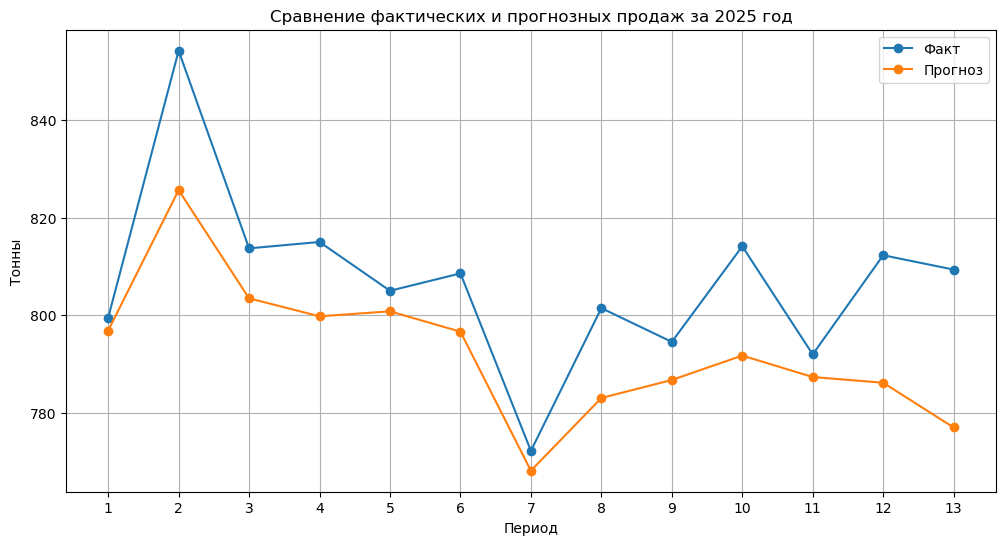

In [6]:
import matplotlib.pyplot as plt

test_df['prediction'] = pred_test

comparison = (test_df.groupby('period_in_year').agg(fact=('tons','sum'),forecast=('prediction','sum')).reset_index())

plt.figure(figsize=(12,6))
plt.plot(comparison['period_in_year'], comparison['fact'], marker='o', label='Факт')
plt.plot(comparison['period_in_year'], comparison['forecast'], marker='o', label='Прогноз')
plt.title('Сравнение фактических и прогнозных продаж за 2025 год')
plt.xlabel('Период')
plt.ylabel('Тонны')
plt.xticks(range(1,14))
plt.legend()
plt.grid()

plt.show()

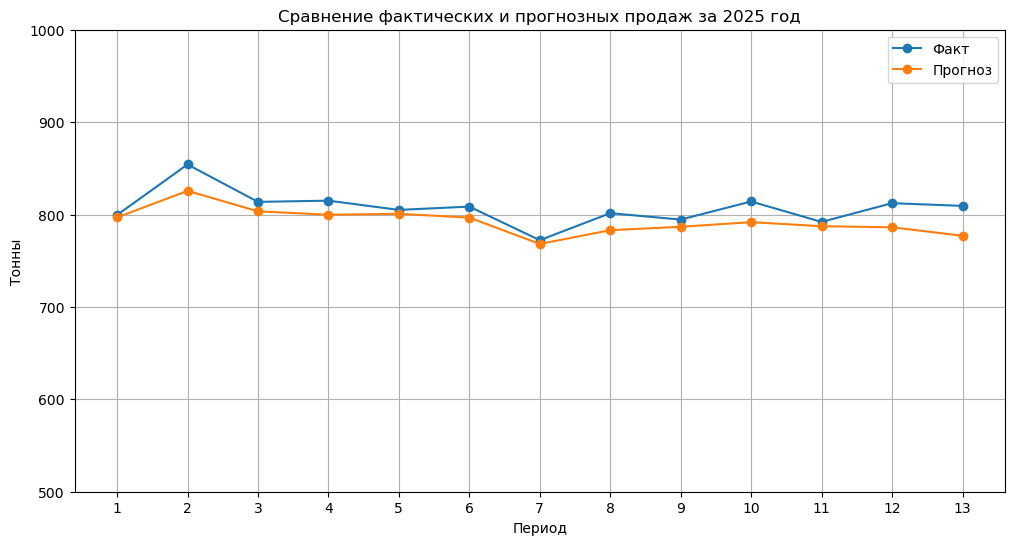

In [7]:
import matplotlib.pyplot as plt

test_df['prediction'] = pred_test

comparison = (
    test_df.groupby('period_in_year')
    .agg(
        fact=('tons', 'sum'),
        forecast=('prediction', 'sum')
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(comparison['period_in_year'],
         comparison['fact'],
         marker='o',
         label='Факт')

plt.plot(comparison['period_in_year'],
         comparison['forecast'],
         marker='o',
         label='Прогноз')

plt.title('Сравнение фактических и прогнозных продаж за 2025 год')
plt.xlabel('Период')
plt.ylabel('Тонны')
plt.xticks(range(1, 14))

# начало оси Y с нуля
plt.ylim(500, 1000)

plt.legend()
plt.grid()

plt.show()

In [10]:
for client in sorted(test_df['client_id'].unique()):

    client_df = test_df[test_df['client_id'] == client].copy()

    print(f'Клиент {client}: {len(client_df)} строк')

    comparison_client = (
        client_df.groupby('period_in_year')
        .agg(
            fact=('tons', 'sum'),
            forecast=('prediction', 'sum')
        )
        .reset_index()
    )

    print(comparison_client)

Клиент client_1: 195 строк
    period_in_year        fact    forecast
0                1  425.447130  425.453061
1                2  455.786812  432.999183
2                3  438.162653  418.786722
3                4  435.538552  421.747527
4                5  430.779680  422.946017
5                6  431.790301  421.693908
6                7  409.640998  406.909118
7                8  425.989878  415.380295
8                9  422.020143  418.292373
9               10  428.798336  418.066586
10              11  416.672100  413.063500
11              12  435.111781  417.019247
12              13  433.052039  411.655303
Клиент client_2: 195 строк
    period_in_year        fact    forecast
0                1  254.436342  249.924311
1                2  272.343030  265.980679
2                3  255.826718  259.809245
3                4  258.561022  255.180075
4                5  253.195598  253.345859
5                6  253.074450  251.047753
6                7  245.983955  241.342124



Клиент: client_1
MAE  = 1.30
RMSE = 1.66
MAPE = 4.47%


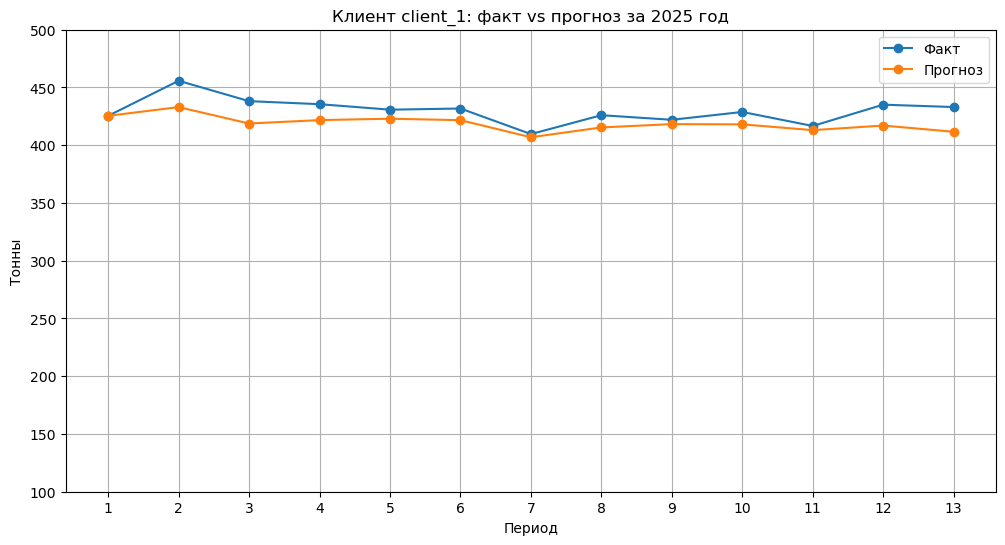


Клиент: client_2
MAE  = 0.82
RMSE = 1.06
MAPE = 4.70%


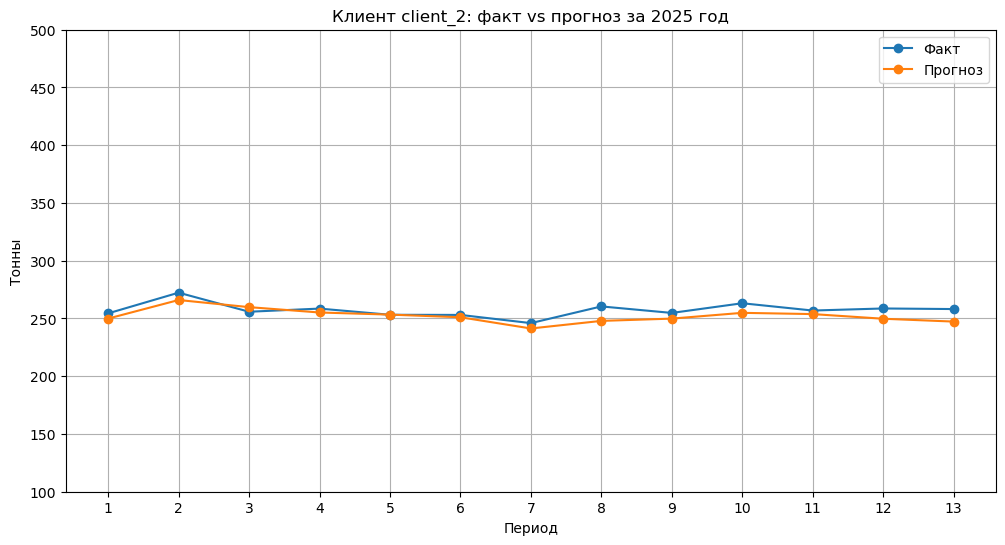


Клиент: client_3
MAE  = 0.40
RMSE = 0.51
MAPE = 5.10%


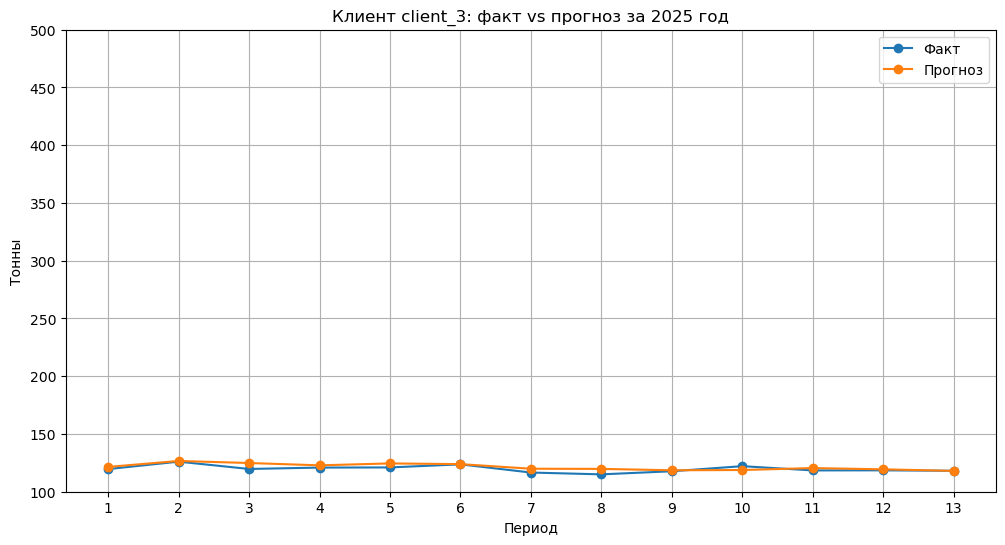

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

for client in sorted(test_df['client_id'].unique()):

    client_df = test_df[test_df['client_id'] == client].copy()

    mae = mean_absolute_error(
        client_df['tons'],
        client_df['prediction']
    )

    rmse = np.sqrt(
        mean_squared_error(
            client_df['tons'],
            client_df['prediction']
        )
    )

    mape = (
        np.abs(
            (client_df['tons'] - client_df['prediction'])
            / client_df['tons']
        )
    ).mean() * 100

    print(f'\nКлиент: {client}')
    print(f'MAE  = {mae:.2f}')
    print(f'RMSE = {rmse:.2f}')
    print(f'MAPE = {mape:.2f}%')

    comparison_client = (
        client_df
        .groupby('period_in_year')
        .agg(
            fact=('tons', 'sum'),
            forecast=('prediction', 'sum')
        )
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        comparison_client['period_in_year'],
        comparison_client['fact'],
        marker='o',
        label='Факт'
    )

    plt.plot(
        comparison_client['period_in_year'],
        comparison_client['forecast'],
        marker='o',
        label='Прогноз'
    )

    plt.title(f'Клиент {client}: факт vs прогноз за 2025 год')
    plt.xlabel('Период')
    plt.ylabel('Тонны')

    plt.xticks(range(1, 14))
    plt.ylim(100, 500)

    plt.legend()
    plt.grid()

    plt.show()

              feature  importance
0           client_id   52.352181
14         tons_lag13   20.046663
13          tons_lag1   16.126349
15           tons_ma3    8.289890
9          promo_days    0.628366
5      period_in_year    0.408633
6          period_abs    0.382422
11  nestle_effect_pct    0.361255
10        promo_depth    0.301464
7               trend    0.270518
12    mars_effect_pct    0.240514
2          technology    0.190614
8            trend_sq    0.182421
1               brand    0.096456
4              bts_id    0.065921
3           weight_kg    0.056332


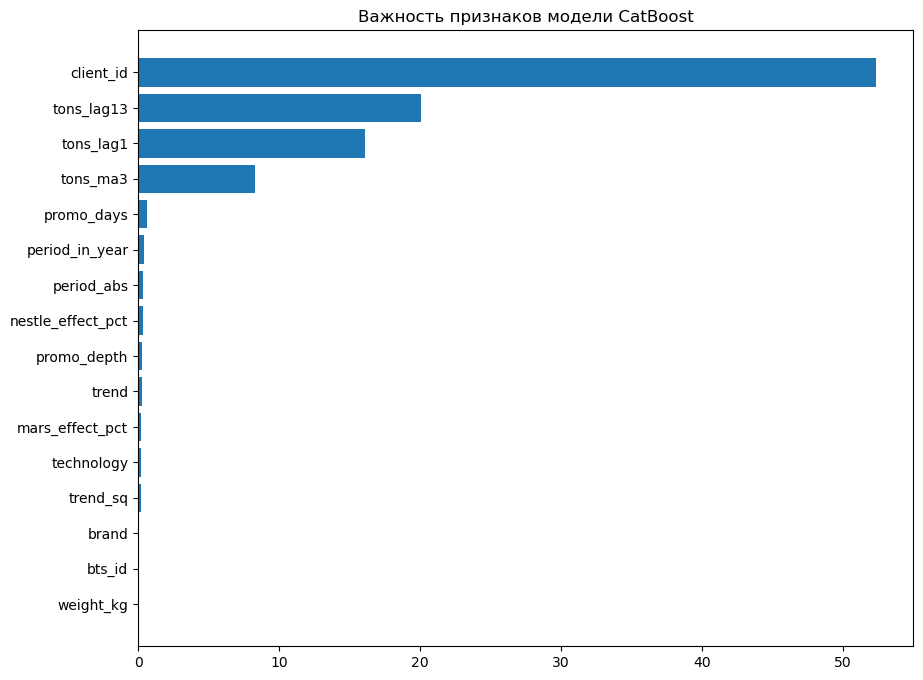

In [47]:
importance = pd.DataFrame({'feature': features, 'importance': model.get_feature_importance()})
importance = importance.sort_values('importance', ascending=False)
print(importance)

plt.figure(figsize=(10,8))
plt.barh(importance['feature'][::-1],importance['importance'][::-1])
plt.title('Важность признаков модели CatBoost')
plt.show()

In [49]:
group_cols = [
    'client_id',
    'brand',
    'technology',
    'weight_kg'
]

forecast_base = forecast_base.sort_values(group_cols + ['period_abs'])
forecast_base['forecast_tons'] = np.nan
history_sales = train_data_clean[group_cols + ['period_abs','tons']].copy()

for period in range(1,14):
    current_mask = forecast_base['period_in_year'] == period
    current_data = forecast_base.loc[current_mask].copy()
    preds = model.predict(current_data[features])
    forecast_base.loc[current_mask,'forecast_tons'] = preds
    predicted_rows = current_data[group_cols + ['period_abs']].copy()
    predicted_rows['tons'] = preds
    history_sales = pd.concat([history_sales, predicted_rows])

    if period < 13:
        next_mask = forecast_base['period_in_year'] == period + 1
        next_rows = forecast_base.loc[next_mask]
        lag1_values = []
        ma3_values = []

        for _, row in next_rows.iterrows():
            hist = history_sales[
                (history_sales['client_id'] == row['client_id']) &
                (history_sales['brand'] == row['brand']) &
                (history_sales['technology'] == row['technology']) &
                (history_sales['weight_kg'] == row['weight_kg'])
            ].sort_values('period_abs')

            lag1_values.append(hist.iloc[-1]['tons'])
            ma3_values.append(hist.tail(3)['tons'].mean())

        forecast_base.loc[next_mask, 'tons_lag1'] = lag1_values
        forecast_base.loc[next_mask, 'tons_ma3'] = ma3_values

forecast_2026 = forecast_base.copy()
forecast_2026.to_excel('forecast_2026.xlsx', index=False)

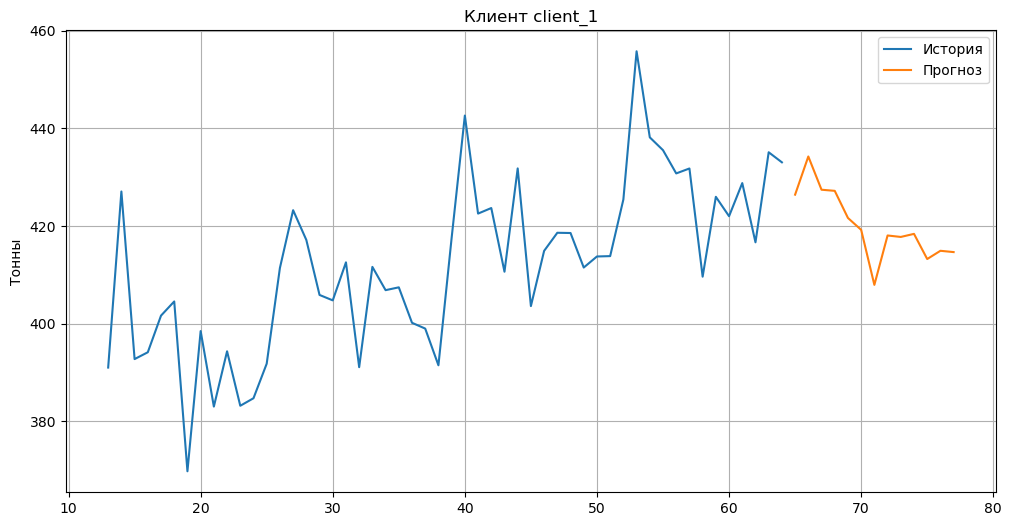

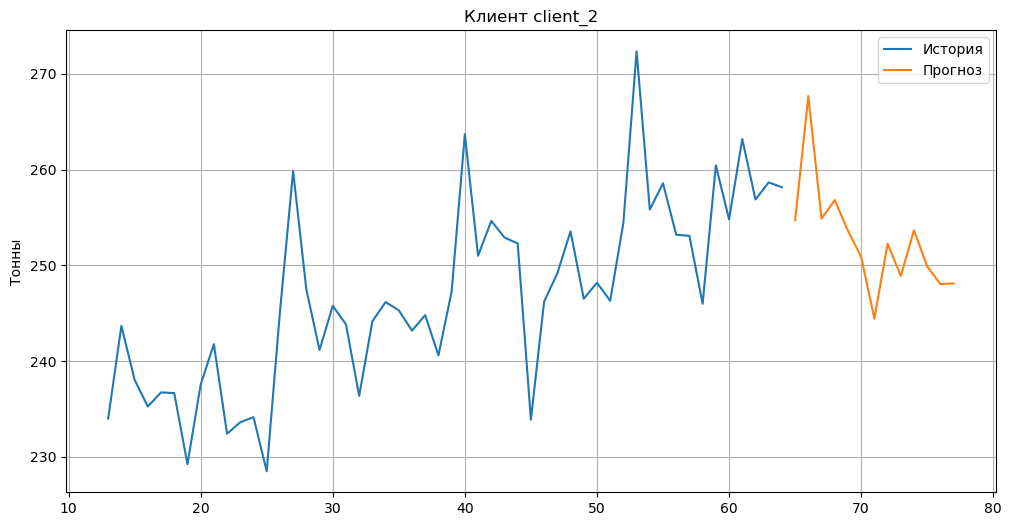

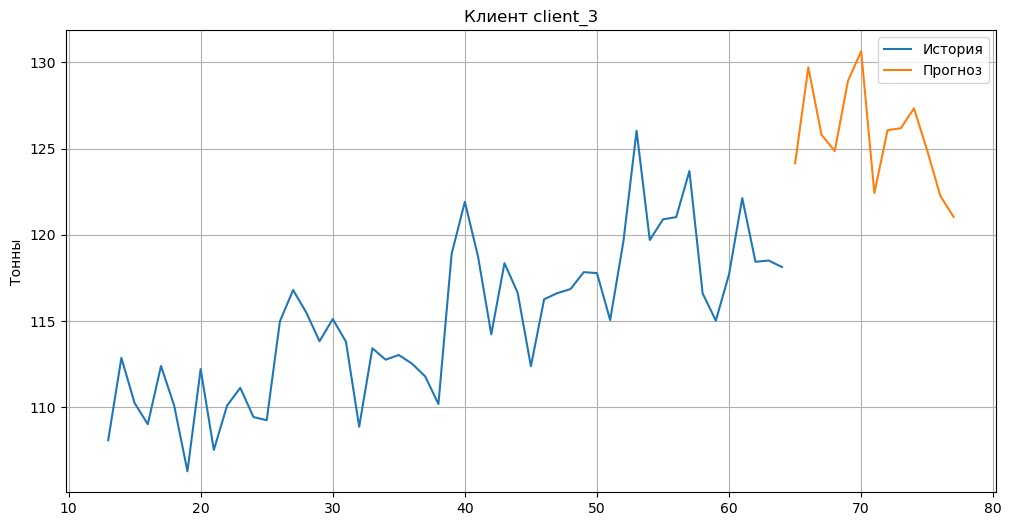

In [50]:
for client in train_data_clean['client_id'].unique():

    hist = (train_data_clean[train_data_clean['client_id'] == client].groupby('period_abs')['tons'].sum().reset_index())
    
    fcst = (forecast_2026[forecast_2026['client_id']== client].groupby('period_abs')['forecast_tons'].sum().reset_index())
    
    plt.figure(figsize=(12,6))
    plt.plot(hist['period_abs'], hist['tons'], label='История')
    plt.plot(fcst['period_abs'], fcst['forecast_tons'], label='Прогноз')
    plt.title(f'Клиент {client}')
    plt.ylabel('Тонны')
    plt.legend()
    plt.grid()
    plt.show()